In [1]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [2]:
# Importing dataset 
df = pd.read_csv("/Users/sushil0711/Downloads/sms_spam.csv")
df.head()

,type,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [3]:
df.shape

(5574, 2)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5574 entries, 0 to 5573
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   type    5574 non-null   object
 1   text    5574 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [5]:
df.dtypes

type    object
text    object
dtype: object

In [6]:
df.duplicated().sum()
df.drop_duplicates(keep = "first", inplace = True)
df.shape

(5160, 2)

In [7]:
df.isnull().sum()

type    0
text    0
dtype: int64

In [8]:
df.head()

,type,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


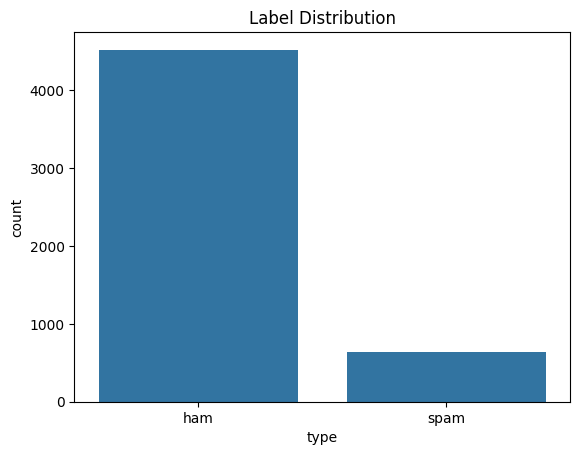

In [9]:
# Visualize the distribution of spam and ham  
sns.countplot(x='type', data=df)
plt.title("Label Distribution")
plt.show()

In [10]:
# Extract independent variable (text data) and dependent variable (email classification label)
X = df["text"]
y = df["type"]

In [11]:
# Convert categorical labels (e.g., spam/ham) into numeric format
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(y)

In [24]:
print(y)

[0 0 1 ... 0 0 0]


In [12]:
# Split data into train and test sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [13]:
# Apply TF-IDF (Term Frequency–Inverse Document Frequency) to convert text data into numerical features for model training
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer()
vectorizer.fit(X_train)
X_train = vectorizer.transform(X_train)
X_test = vectorizer.transform(X_test)

In [14]:
# Training the model on the given dataset 
from sklearn.svm import SVC 
classifier = SVC(kernel= "linear", random_state = 0)
classifier.fit(X_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [15]:
# Predicting test set results 
y_pred = classifier.predict(X_test)
results = pd.DataFrame({
    "predicted" : y_pred, 
    "Actual" : y_test
}) 
results 

,predicted,Actual
0,0,0
1,0,0
2,0,0
3,0,0
4,0,0
...,...,...
1027,0,0
1028,0,0
1029,0,0
1030,0,0


In [16]:
# Compute confusion matrix to visualize prediction results (TN, FP, FN, TP)
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
cm = confusion_matrix(y_test, y_pred)
print(cm)
accuracy_score(y_test, y_pred)

[[912   4]
 [ 16 100]]


0.9806201550387597

In [17]:
precision_score(y_test, y_pred)

0.9615384615384616

In [18]:
recall_score(y_test, y_pred)

0.8620689655172413

In [19]:
f1_score(y_test, y_pred)

0.9090909090909091

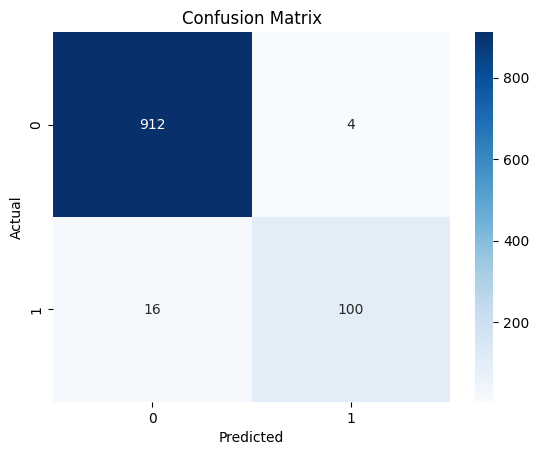

In [20]:
# Visualize the confusion matrix using a heatmap
# Helps in understanding model performance (TN, FP, FN, TP)
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot = True, fmt = "d", cmap = "Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [21]:
# Save trained model and feature columns as a pickle file
import joblib 

joblib.dump({
    "model": classifier,
    "vectorizer": vectorizer,
    "label_mapping": {"ham": 0, "spam": 1}
}, "spamemailclassifier.pkl")

['spamemailclassifier.pkl']